<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/thermodynamics/PhysicalPropertiesOfAmmonia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Physical properties of ammonia with NeqSim

**Audience.** Process, refrigeration, and energy engineers who need reproducible ammonia property
calculations for screening studies and process models.

**Prerequisites.** Introductory thermodynamics, basic Python, and familiarity with temperature,
pressure, density, heat capacity, viscosity, and thermal conductivity.

**Learning objectives**

- construct pure anhydrous ammonia with supported NeqSim models;
- distinguish thermodynamic, caloric, transport, and phase-specific properties;
- benchmark dilute-gas heat capacity against the public NIST Shomate correlation;
- verify density and heat-capacity identities by independent finite differences;
- quantify temperature, pressure, phase, and model sensitivities;
- translate properties into Reynolds, Prandtl, and Nusselt numbers;
- integrate an ammonia stream and cooler in a NeqSim process; and
- recognize model, phase, safety, and heat-transfer validity limits.

All examples are educational screening calculations, not equipment certification or a safety design.

In [1]:
import importlib.metadata
import subprocess
import sys


try:
    neqsim_version = importlib.metadata.version("neqsim")
except importlib.metadata.PackageNotFoundError:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            "--quiet",
            "neqsim",
        ]
    )
    neqsim_version = importlib.metadata.version("neqsim")

print(f"NeqSim version: {neqsim_version}")

NeqSim version: 3.16.0


## 1. Calculation architecture, units, and model strategy

A NeqSim thermodynamic system stores components, mole amounts, an equation of state, temperature,
pressure, and phases. `ThermodynamicOperations` establishes equilibrium with a flash calculation.
`initProperties()` then initializes caloric and transport properties. A stream adds a flow rate to a
cloned fluid, and a unit operation calculates a new outlet state. `runProcess()` solves the connected
flowsheet in order.

Two current public models are used deliberately. `SystemAmmoniaEos` is the ammonia-specific reference
model for the dilute-gas heat-capacity benchmark. Peng-Robinson (PR) is used for robust phase-aware
TP flashes, sensitivities, and process operations; Soave-Redlich-Kwong (SRK) provides a cubic-model
uncertainty check. Model spread is reported rather than hidden.

Displayed units are SI: temperature in K, absolute pressure in MPa, density in kg/m³, heat capacity
in kJ/(kg K), dynamic viscosity in Pa s, thermal conductivity in W/(m K), speed in m/s, mass flow in
kg/s, and duty in kW. NeqSim accepts pressure in `bara`; every input converts with
$1\ \mathrm{MPa}=10\ \mathrm{bar}$.

In [2]:
import math

import jpype
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from neqsim import jneqsim
from neqsim.process import clearProcess, heater, runProcess, stream
from neqsim.thermo import fluid


plt.style.use("seaborn-v0_8-whitegrid")
ThermodynamicOperations = (
    jneqsim.thermodynamicoperations.ThermodynamicOperations
)

python_version = sys.version.split()[0]
java_version = jpype.JClass("java.lang.System").getProperty("java.version")

print(f"Python version: {python_version}")
print(f"Java version: {java_version}")

Python version: 3.12.13
Java version: 17.0.19


## 2. Governing properties and assumptions

Density follows the mass-to-volume definition,

$$
\rho=\frac{M}{v}
$$

where $M$ is molar mass in kg/mol and $v$ is molar volume in m³/mol. Heat capacities are
$c_p=(\partial h/\partial T)_P$ and $c_v=(\partial u/\partial T)_v$. Viscosity $\mu$ controls
momentum diffusion, while thermal conductivity $k$ controls conductive heat transport.

The calculations assume pure anhydrous ammonia, local thermodynamic equilibrium, no reaction, and
no dissolved water, oil, air, or corrosion products. Transport correlations are phase-specific and
should be validated against project data before detailed exchanger, compressor, or piping design.

In [3]:
def run_tp_flash(state):
    operations = ThermodynamicOperations(state)
    operations.TPflash()
    state.initProperties()
    return state


def make_cubic_ammonia(
    temperature_kelvin,
    pressure_mpa,
    model="pr",
):
    state = fluid(
        model,
        temperature=temperature_kelvin,
        pressure=pressure_mpa * 10.0,
    )
    state.addComponent("ammonia", 1.0)
    state.setMultiPhaseCheck(True)
    return run_tp_flash(state)


def make_reference_ammonia(temperature_kelvin, pressure_mpa):
    state = jneqsim.thermo.system.SystemAmmoniaEos(
        temperature_kelvin,
        pressure_mpa * 10.0,
    )
    state.addComponent("ammonia", 1.0)
    state.setMultiPhaseCheck(True)
    return run_tp_flash(state)


def phase_property_record(label, state, phase_index=0):
    phase = state.getPhase(phase_index)
    return {
        "Case": label,
        "Phase": str(phase.getPhaseTypeName()),
        "Density [kg/m³]": phase.getDensity("kg/m3"),
        "Cp [kJ/(kg K)]": phase.getCp("kJ/kgK"),
        "Cv [kJ/(kg K)]": phase.getCv("kJ/kgK"),
        "Viscosity [Pa s]": phase.getViscosity("kg/msec"),
        "Conductivity [W/(m K)]": phase.getThermalConductivity("W/mK"),
        "Sound speed [m/s]": phase.getSoundSpeed(),
        "Compressibility factor [-]": phase.getZ(),
    }

## 3. Baseline gas and liquid states

The dilute gas is evaluated at 323 K and standard absolute pressure with the ammonia-specific model.
The cubic comparison uses the same state. A compressed-liquid screening state is evaluated with PR
at 280 K and 2.0 MPa, safely above the approximately 0.55 MPa saturation pressure.

NeqSim may label the pure polar liquid phase `aqueous`. In this notebook that label means the dense
polar-liquid phase family; no water has been added. Reading each phase explicitly prevents a gas
transport correlation from being confused with a liquid result.

In [4]:
gas_temperature_kelvin = 323.0
gas_pressure_mpa = 0.101325
liquid_temperature_kelvin = 280.0
liquid_pressure_mpa = 2.0

reference_gas = make_reference_ammonia(
    gas_temperature_kelvin,
    gas_pressure_mpa,
)
pr_gas = make_cubic_ammonia(
    gas_temperature_kelvin,
    gas_pressure_mpa,
)
pr_liquid = make_cubic_ammonia(
    liquid_temperature_kelvin,
    liquid_pressure_mpa,
)

baseline_table = pd.DataFrame(
    [
        phase_property_record("Ammonia EOS gas", reference_gas),
        phase_property_record("PR gas", pr_gas),
        phase_property_record("PR compressed liquid", pr_liquid),
    ]
)

print(baseline_table.round(6).to_string(index=False))

                Case   Phase  Density [kg/m³]  Cp [kJ/(kg K)]  Cv [kJ/(kg K)]  Viscosity [Pa s]  Conductivity [W/(m K)]  Sound speed [m/s]  Compressibility factor [-]
     Ammonia EOS gas     gas         0.649170        2.178941        1.670347          0.000011                0.027374         449.986446                    0.989805
              PR gas     gas         0.647114        2.709925        2.209630          0.000010                0.039197         436.814402                    0.993314
PR compressed liquid aqueous       795.973317        5.189578        3.170076          0.000657                0.586592        1534.966380                    0.026035


## 4. Authoritative dilute-gas heat-capacity benchmark

NIST publishes the Shomate ideal-gas correlation from 298 K to 1400 K. In the lower interval,

$$
C_p^\circ=A+Bt+Ct^2+Dt^3+\frac{E}{t^2}
$$

where $t=T/1000$, $C_p^\circ$ is in J/(mol K), and the coefficients are dimensioned consistently.
At 0.01 MPa, residual-pressure effects are small. This is a true external benchmark rather than an
identity check. It also explains why the ammonia-specific model is retained alongside cubic models.

In [5]:
nist_shomate_coefficients = {
    "A": 19.99563,
    "B": 49.77119,
    "C": -15.37599,
    "D": 1.921168,
    "E": 0.189174,
}


def nist_ideal_gas_cp_j_per_mol_k(temperature_kelvin):
    scaled_temperature = temperature_kelvin / 1000.0
    coefficients = nist_shomate_coefficients
    return (
        coefficients["A"]
        + coefficients["B"] * scaled_temperature
        + coefficients["C"] * scaled_temperature**2
        + coefficients["D"] * scaled_temperature**3
        + coefficients["E"] / scaled_temperature**2
    )


benchmark_temperatures_kelvin = np.array([300.0, 330.0, 360.0, 400.0])
benchmark_records = []

for temperature_kelvin in benchmark_temperatures_kelvin:
    benchmark_state = make_reference_ammonia(temperature_kelvin, 0.01)
    neqsim_cp = benchmark_state.getCp("J/molK")
    nist_cp = nist_ideal_gas_cp_j_per_mol_k(temperature_kelvin)
    relative_difference_percent = 100.0 * (neqsim_cp - nist_cp) / nist_cp
    benchmark_records.append(
        {
            "Temperature [K]": temperature_kelvin,
            "NeqSim Cp [J/(mol K)]": neqsim_cp,
            "NIST Cp [J/(mol K)]": nist_cp,
            "Difference [%]": relative_difference_percent,
        }
    )

cp_benchmark_table = pd.DataFrame(benchmark_records)
maximum_cp_difference_percent = cp_benchmark_table["Difference [%]"].abs().max()

print(cp_benchmark_table.round(5).to_string(index=False))
print(f"Maximum absolute difference: {maximum_cp_difference_percent:.4f}%")

 Temperature [K]  NeqSim Cp [J/(mol K)]  NIST Cp [J/(mol K)]  Difference [%]
           300.0               35.69579             35.69695        -0.00325
           330.0               36.53848             36.55185        -0.03658
           360.0               37.44437             37.46984        -0.06799
           400.0               38.70394             38.74924        -0.11690
Maximum absolute difference: 0.1169%


## 5. Independent thermodynamic identity check

Central finite differences provide the isobaric expansivity $\alpha$ and isothermal compressibility
$\kappa_T$:

$$
\alpha=-\frac{1}{\rho}\left(\frac{\partial\rho}{\partial T}\right)_P
$$

$$
\kappa_T=\frac{1}{\rho}\left(\frac{\partial\rho}{\partial P}\right)_T
$$

For a stable single phase, the exact identity is

$$
c_p-c_v=\frac{T\alpha^2}{\rho\kappa_T}
$$

This check independently exercises multiple flashes, density derivatives, units, and caloric
properties. Small steps are used away from phase boundaries.

In [6]:
def density_at_cubic_state(temperature_kelvin, pressure_mpa):
    state = make_cubic_ammonia(temperature_kelvin, pressure_mpa)
    return state.getDensity("kg/m3")


def derivative_identity_record(label, temperature_kelvin, pressure_mpa):
    state = make_cubic_ammonia(temperature_kelvin, pressure_mpa)
    density = state.getDensity("kg/m3")
    cp_j_per_kg_k = state.getCp("kJ/kgK") * 1000.0
    cv_j_per_kg_k = state.getCv("kJ/kgK") * 1000.0
    temperature_step_kelvin = 0.01
    pressure_step_mpa = 0.001

    density_high_temperature = density_at_cubic_state(
        temperature_kelvin + temperature_step_kelvin,
        pressure_mpa,
    )
    density_low_temperature = density_at_cubic_state(
        temperature_kelvin - temperature_step_kelvin,
        pressure_mpa,
    )
    density_high_pressure = density_at_cubic_state(
        temperature_kelvin,
        pressure_mpa + pressure_step_mpa,
    )
    density_low_pressure = density_at_cubic_state(
        temperature_kelvin,
        pressure_mpa - pressure_step_mpa,
    )

    density_temperature_derivative = (
        density_high_temperature - density_low_temperature
    ) / (2.0 * temperature_step_kelvin)
    density_pressure_derivative = (
        density_high_pressure - density_low_pressure
    ) / (2.0 * pressure_step_mpa * 1.0e6)

    expansivity_per_kelvin = -density_temperature_derivative / density
    compressibility_per_pascal = density_pressure_derivative / density
    derivative_cp_minus_cv = (
        temperature_kelvin
        * expansivity_per_kelvin**2
        / (density * compressibility_per_pascal)
    )
    reported_cp_minus_cv = cp_j_per_kg_k - cv_j_per_kg_k
    relative_residual = (
        derivative_cp_minus_cv - reported_cp_minus_cv
    ) / reported_cp_minus_cv

    return {
        "Case": label,
        "Alpha [1/K]": expansivity_per_kelvin,
        "Kappa_T [1/Pa]": compressibility_per_pascal,
        "Reported Cp-Cv [J/(kg K)]": reported_cp_minus_cv,
        "Derivative Cp-Cv [J/(kg K)]": derivative_cp_minus_cv,
        "Relative residual [-]": relative_residual,
    }


identity_table = pd.DataFrame(
    [
        derivative_identity_record("Gas", 330.0, 1.5),
        derivative_identity_record("Liquid", 280.0, 2.0),
    ]
)
maximum_identity_residual = identity_table["Relative residual [-]"].abs().max()

print(identity_table.to_string(index=False))

  Case  Alpha [1/K]  Kappa_T [1/Pa]  Reported Cp-Cv [J/(kg K)]  Derivative Cp-Cv [J/(kg K)]  Relative residual [-]
   Gas     0.004113    7.505605e-07                 715.347232                   715.347227          -7.776009e-09
Liquid     0.003171    1.751079e-09                2019.501381                  2019.501385           2.124900e-09


## 6. Dilute-gas temperature sensitivity

At fixed low pressure, gas density should decrease as temperature increases. Molecular momentum and
energy transport normally make dilute-gas viscosity and thermal conductivity increase with
temperature. The ammonia-specific model is used because this sweep stays in its demonstrated
single-gas-phase region.

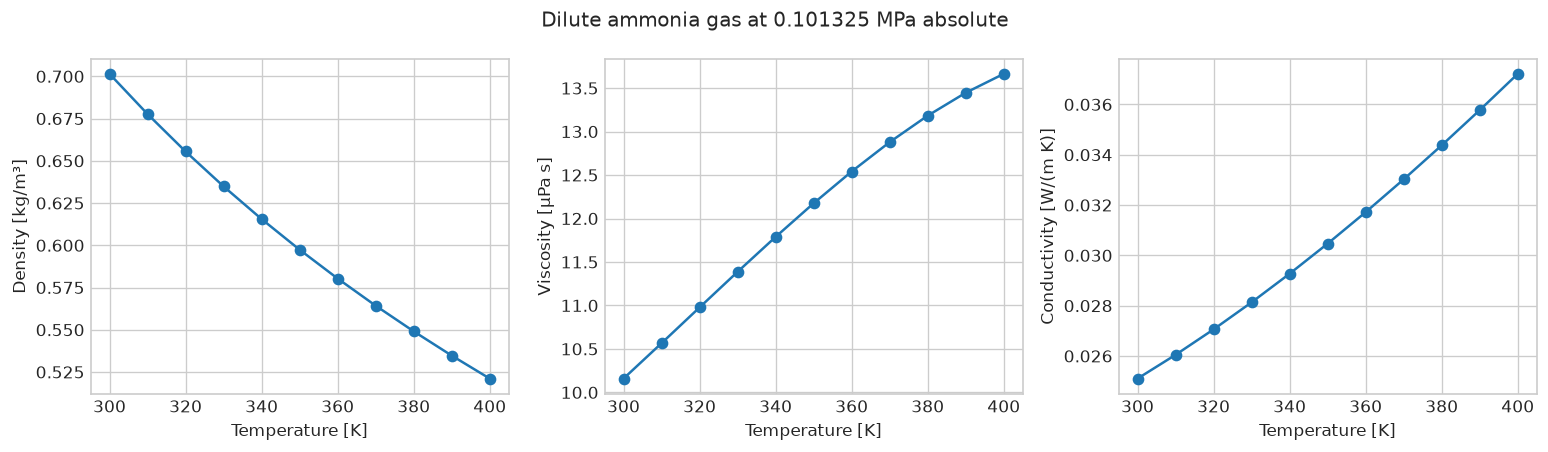

In [7]:
gas_sweep_temperatures_kelvin = np.linspace(300.0, 400.0, 11)
gas_sweep_records = []

for temperature_kelvin in gas_sweep_temperatures_kelvin:
    sweep_state = make_reference_ammonia(temperature_kelvin, 0.101325)
    sweep_phase = sweep_state.getPhase(0)
    gas_sweep_records.append(
        {
            "Temperature [K]": temperature_kelvin,
            "Density [kg/m³]": sweep_phase.getDensity("kg/m3"),
            "Viscosity [Pa s]": sweep_phase.getViscosity("kg/msec"),
            "Conductivity [W/(m K)]": sweep_phase.getThermalConductivity("W/mK"),
            "Cp [kJ/(kg K)]": sweep_phase.getCp("kJ/kgK"),
        }
    )

gas_sweep_table = pd.DataFrame(gas_sweep_records)

figure, axes = plt.subplots(1, 3, figsize=(13, 3.8))
axes[0].plot(
    gas_sweep_table["Temperature [K]"],
    gas_sweep_table["Density [kg/m³]"],
    marker="o",
)
axes[1].plot(
    gas_sweep_table["Temperature [K]"],
    gas_sweep_table["Viscosity [Pa s]"] * 1.0e6,
    marker="o",
)
axes[2].plot(
    gas_sweep_table["Temperature [K]"],
    gas_sweep_table["Conductivity [W/(m K)]"],
    marker="o",
)
axes[0].set_ylabel("Density [kg/m³]")
axes[1].set_ylabel("Viscosity [µPa s]")
axes[2].set_ylabel("Conductivity [W/(m K)]")

for axis in axes:
    axis.set_xlabel("Temperature [K]")

figure.suptitle("Dilute ammonia gas at 0.101325 MPa absolute")
figure.tight_layout()
plt.show()

## 7. Compressed-liquid temperature sensitivity

The PR sweep remains at 2.0 MPa and between 260 K and 310 K. That pressure is above the saturation
pressure throughout this interval, so the results remain in the dense liquid phase. Density and
viscosity are expected to fall as thermal motion increases. Absolute values remain model-dependent,
especially for a small associating molecule represented by a cubic EOS.

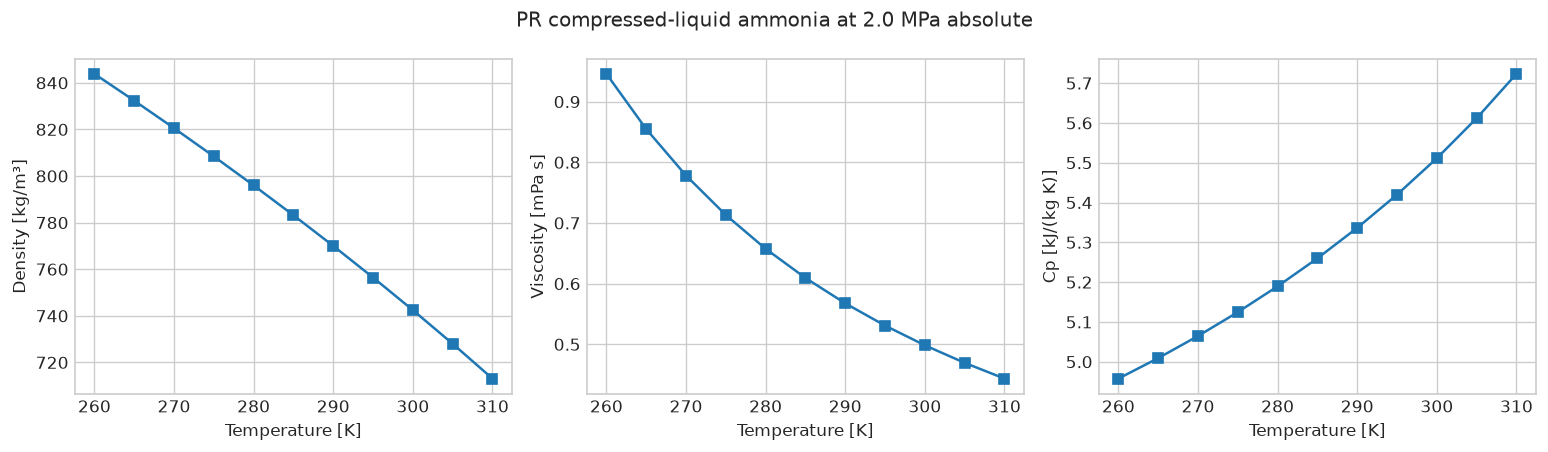

In [8]:
liquid_sweep_temperatures_kelvin = np.linspace(260.0, 310.0, 11)
liquid_sweep_records = []

for temperature_kelvin in liquid_sweep_temperatures_kelvin:
    sweep_state = make_cubic_ammonia(temperature_kelvin, 2.0)
    sweep_phase = sweep_state.getPhase(0)
    liquid_sweep_records.append(
        {
            "Temperature [K]": temperature_kelvin,
            "Phase": str(sweep_phase.getPhaseTypeName()),
            "Density [kg/m³]": sweep_phase.getDensity("kg/m3"),
            "Viscosity [Pa s]": sweep_phase.getViscosity("kg/msec"),
            "Conductivity [W/(m K)]": sweep_phase.getThermalConductivity("W/mK"),
            "Cp [kJ/(kg K)]": sweep_phase.getCp("kJ/kgK"),
        }
    )

liquid_sweep_table = pd.DataFrame(liquid_sweep_records)

figure, axes = plt.subplots(1, 3, figsize=(13, 3.8))
axes[0].plot(
    liquid_sweep_table["Temperature [K]"],
    liquid_sweep_table["Density [kg/m³]"],
    marker="s",
)
axes[1].plot(
    liquid_sweep_table["Temperature [K]"],
    liquid_sweep_table["Viscosity [Pa s]"] * 1.0e3,
    marker="s",
)
axes[2].plot(
    liquid_sweep_table["Temperature [K]"],
    liquid_sweep_table["Cp [kJ/(kg K)]"],
    marker="s",
)
axes[0].set_ylabel("Density [kg/m³]")
axes[1].set_ylabel("Viscosity [mPa s]")
axes[2].set_ylabel("Cp [kJ/(kg K)]")

for axis in axes:
    axis.set_xlabel("Temperature [K]")

figure.suptitle("PR compressed-liquid ammonia at 2.0 MPa absolute")
figure.tight_layout()
plt.show()

## 8. Gas pressure sensitivity and the Joule-Thomson coefficient

At 330 K, the saturation pressure is about 2.44 MPa, so the range from 0.2 MPa to 2.0 MPa remains
gaseous. Density should rise with pressure. The compressibility factor $Z=Pv/(RT)$ measures
departure from ideal-gas behavior. NeqSim reports the Joule-Thomson coefficient in K/bar; positive
$\mu_{JT}=(\partial T/\partial P)_h$ implies cooling during an isenthalpic pressure drop.

 Pressure [MPa abs]  Density [kg/m³]    Z [-]  Joule-Thomson [K/bar]
                0.2         1.257928 0.987534               1.051442
                0.4         2.550313 0.974849               1.062745
                0.6         3.879532 0.961932               1.074551
                0.8         5.248244 0.948765               1.086905
                1.0         6.659437 0.935330               1.099855
                1.2         8.116491 0.921605               1.113456
                1.4         9.623250 0.907567               1.127774
                1.6        11.184120 0.893189               1.142882
                1.8        12.804187 0.878439               1.158867
                2.0        14.489375 0.863280               1.175829


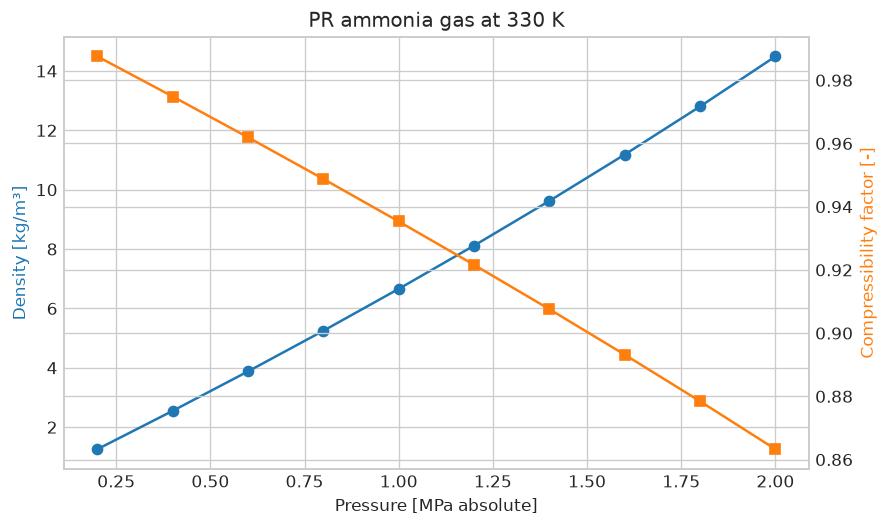

In [9]:
gas_sweep_pressures_mpa = np.linspace(0.2, 2.0, 10)
pressure_sweep_records = []

for pressure_mpa in gas_sweep_pressures_mpa:
    sweep_state = make_cubic_ammonia(330.0, pressure_mpa)
    sweep_phase = sweep_state.getPhase(0)
    pressure_sweep_records.append(
        {
            "Pressure [MPa abs]": pressure_mpa,
            "Density [kg/m³]": sweep_phase.getDensity("kg/m3"),
            "Z [-]": sweep_phase.getZ(),
            "Joule-Thomson [K/bar]": sweep_phase.getJouleThomsonCoefficient(),
        }
    )

pressure_sweep_table = pd.DataFrame(pressure_sweep_records)

figure, density_axis = plt.subplots(figsize=(7.5, 4.5))
z_axis = density_axis.twinx()
density_axis.plot(
    pressure_sweep_table["Pressure [MPa abs]"],
    pressure_sweep_table["Density [kg/m³]"],
    marker="o",
    color="tab:blue",
    label="Density",
)
z_axis.plot(
    pressure_sweep_table["Pressure [MPa abs]"],
    pressure_sweep_table["Z [-]"],
    marker="s",
    color="tab:orange",
    label="Compressibility factor",
)
density_axis.set_xlabel("Pressure [MPa absolute]")
density_axis.set_ylabel("Density [kg/m³]", color="tab:blue")
z_axis.set_ylabel("Compressibility factor [-]", color="tab:orange")
density_axis.set_title("PR ammonia gas at 330 K")
figure.tight_layout()
plt.show()

print(pressure_sweep_table.round(6).to_string(index=False))

## 9. Model sensitivity is engineering uncertainty

PR, SRK, and the ammonia-specific EOS make different compromises. A gas comparison uses all three
models. The liquid comparison uses PR and SRK because the current ammonia-specific implementation
is used here only in its verified single-gas region. Model spread is not statistical uncertainty,
but it is an immediate warning when a design depends strongly on model choice.

In [10]:
model_records = []

for model_name in ["pr", "srk"]:
    gas_model_state = make_cubic_ammonia(330.0, 1.5, model=model_name)
    liquid_model_state = make_cubic_ammonia(280.0, 2.0, model=model_name)
    model_records.append(
        phase_property_record(f"{model_name.upper()} gas", gas_model_state)
    )
    model_records.append(
        phase_property_record(f"{model_name.upper()} liquid", liquid_model_state)
    )

reference_model_state = make_reference_ammonia(330.0, 1.5)
model_records.append(
    phase_property_record("Ammonia EOS gas", reference_model_state)
)

model_table = pd.DataFrame(model_records)
gas_model_table = model_table[model_table["Case"].str.contains("gas")]
liquid_model_table = model_table[model_table["Case"].str.contains("liquid")]

gas_density_spread_percent = 100.0 * (
    gas_model_table["Density [kg/m³]"].max()
    - gas_model_table["Density [kg/m³]"].min()
) / gas_model_table["Density [kg/m³]"].mean()
liquid_density_spread_percent = 100.0 * (
    liquid_model_table["Density [kg/m³]"].max()
    - liquid_model_table["Density [kg/m³]"].min()
) / liquid_model_table["Density [kg/m³]"].mean()

selected_columns = [
    "Case",
    "Phase",
    "Density [kg/m³]",
    "Cp [kJ/(kg K)]",
    "Viscosity [Pa s]",
    "Conductivity [W/(m K)]",
]

print(model_table[selected_columns].round(6).to_string(index=False))
print(f"Gas density model spread: {gas_density_spread_percent:.2f}%")
print(f"Liquid density model spread: {liquid_density_spread_percent:.2f}%")

           Case   Phase  Density [kg/m³]  Cp [kJ/(kg K)]  Viscosity [Pa s]  Conductivity [W/(m K)]
         PR gas     gas        10.396621        2.980680          0.000010                0.043043
      PR liquid aqueous       795.973317        5.189578          0.000657                0.586592
        SRK gas     gas        10.343182        2.987356          0.000010                0.043043
     SRK liquid aqueous       746.626873        5.430747          0.000657                0.586592
Ammonia EOS gas     gas        11.246967        3.116606          0.000011                0.030002
Gas density model spread: 8.48%
Liquid density model spread: 6.40%


## 10. Saturated phases at one equilibrium state

At fixed temperature, a bubble-pressure flash finds a pressure at which liquid and vapor coexist.
Each phase then has its own density, heat capacity, viscosity, conductivity, and sound speed. The
large density and transport-property contrasts explain why two-phase equipment cannot be sized
with one bulk single-phase property value.

In [11]:
saturated_ammonia = fluid(
    "pr",
    temperature=300.0,
    pressure=10.0,
)
saturated_ammonia.addComponent("ammonia", 1.0)
saturated_ammonia.setMultiPhaseCheck(True)
saturation_operations = ThermodynamicOperations(saturated_ammonia)
saturation_operations.bubblePointPressureFlash()
saturated_ammonia.initProperties()

saturation_pressure_mpa = saturated_ammonia.getPressure("bara") * 0.1
saturation_records = []

for phase_index in range(saturated_ammonia.getNumberOfPhases()):
    label = f"Saturated phase {phase_index}"
    saturation_records.append(
        phase_property_record(label, saturated_ammonia, phase_index)
    )

saturation_table = pd.DataFrame(saturation_records)
saturation_table = saturation_table.sort_values("Density [kg/m³]")
saturation_density_ratio = (
    saturation_table["Density [kg/m³]"].max()
    / saturation_table["Density [kg/m³]"].min()
)

print(f"Saturation pressure at 300 K: {saturation_pressure_mpa:.5f} MPa absolute")
print(saturation_table.round(6).to_string(index=False))
print(f"Liquid-to-vapor density ratio: {saturation_density_ratio:.2f}")

Saturation pressure at 300 K: 1.06845 MPa absolute
             Case   Phase  Density [kg/m³]  Cp [kJ/(kg K)]  Cv [kJ/(kg K)]  Viscosity [Pa s]  Conductivity [W/(m K)]  Sound speed [m/s]  Compressibility factor [-]
Saturated phase 0     gas         8.074477        2.825029        2.139321          0.000009                0.037356         397.488878                    0.907306
Saturated phase 1 aqueous       740.694629        5.531980        3.164521          0.000497                0.617700        1329.757754                    0.013665
Liquid-to-vapor density ratio: 91.73


## 11. From properties to heat-transfer screening

For internal flow through a circular tube,

$$
\mathrm{Re}=\frac{\rho uD}{\mu}
$$

$$
\mathrm{Pr}=\frac{c_p\mu}{k}
$$

For fully developed turbulent flow in a smooth tube, the Dittus-Boelter screening correlation is

$$
\mathrm{Nu}=0.023\mathrm{Re}^{0.8}\mathrm{Pr}^{0.4}
$$

and $h=\mathrm{Nu}k/D$. The exponent 0.4 is used for heating the fluid. This correlation is only a
screening tool for approximately $\mathrm{Re}>10{,}000$, $0.7<\mathrm{Pr}<160$, and a sufficiently
long smooth tube. It does not cover boiling, condensation, entrance effects, or roughness.

In [12]:
screening_state = make_reference_ammonia(323.0, 0.101325)
screening_phase = screening_state.getPhase(0)

tube_diameter_metre = 0.05
mass_flow_kg_per_s = 0.02
flow_area_square_metre = math.pi * tube_diameter_metre**2 / 4.0
density_kg_per_m3 = screening_phase.getDensity("kg/m3")
viscosity_pa_s = screening_phase.getViscosity("kg/msec")
conductivity_w_per_m_k = screening_phase.getThermalConductivity("W/mK")
cp_j_per_kg_k = screening_phase.getCp("kJ/kgK") * 1000.0
velocity_m_per_s = mass_flow_kg_per_s / (
    density_kg_per_m3 * flow_area_square_metre
)
reynolds_number = (
    density_kg_per_m3
    * velocity_m_per_s
    * tube_diameter_metre
    / viscosity_pa_s
)
prandtl_number = cp_j_per_kg_k * viscosity_pa_s / conductivity_w_per_m_k
nusselt_number = 0.023 * reynolds_number**0.8 * prandtl_number**0.4
heat_transfer_coefficient_w_per_m2_k = (
    nusselt_number * conductivity_w_per_m_k / tube_diameter_metre
)

heat_transfer_table = pd.DataFrame(
    {
        "Quantity": [
            "Mean velocity",
            "Reynolds number",
            "Prandtl number",
            "Nusselt number",
            "Heat-transfer coefficient",
        ],
        "Value": [
            velocity_m_per_s,
            reynolds_number,
            prandtl_number,
            nusselt_number,
            heat_transfer_coefficient_w_per_m2_k,
        ],
        "Unit": ["m/s", "-", "-", "-", "W/(m² K)"],
    }
)

print(heat_transfer_table.round(4).to_string(index=False))

                 Quantity      Value     Unit
            Mean velocity    15.6907      m/s
          Reynolds number 45879.9752        -
           Prandtl number     0.8836        -
           Nusselt number   117.3622        -
Heat-transfer coefficient    64.2533 W/(m² K)


## 12. NeqSim stream and cooler workflow

The process example uses PR because it connects phase-aware thermodynamics to a standard NeqSim
stream and heater object operated as a cooler. For a steady unit with negligible kinetic and
potential energy changes and no shaft work,

$$
\dot Q=\dot m(h_{out}-h_{in})
$$

A negative duty means heat is removed. The inlet is 0.5 kg/s of ammonia at 330 K and 1.5 MPa. The
baseline outlet is 315 K at the same pressure, so the calculation remains on the gas side of the
phase boundary.

In [13]:
def run_cooler_case(outlet_temperature_kelvin):
    clearProcess()
    inlet_state = make_cubic_ammonia(330.0, 1.5)
    inlet_stream = stream("Ammonia feed", inlet_state)
    inlet_stream.setFlowRate(0.5, "kg/sec")
    cooler_unit = heater("Ammonia cooler", inlet_stream)
    cooler_unit.setOutTemperature(outlet_temperature_kelvin, "K")
    runProcess()

    outlet_stream = cooler_unit.getOutletStream()
    inlet_enthalpy_kj_per_kg = inlet_stream.getFluid().getEnthalpy("kJ/kg")
    outlet_enthalpy_kj_per_kg = outlet_stream.getFluid().getEnthalpy("kJ/kg")
    duty_kw = cooler_unit.getDuty("kW")
    calculated_duty_kw = 0.5 * (
        outlet_enthalpy_kj_per_kg - inlet_enthalpy_kj_per_kg
    )
    energy_residual_kw = duty_kw - calculated_duty_kw

    return {
        "Outlet temperature [K]": outlet_stream.getTemperature("K"),
        "Outlet phase": str(outlet_stream.getFluid().getPhase(0).getPhaseTypeName()),
        "Duty [kW]": duty_kw,
        "Energy residual [kW]": energy_residual_kw,
        "Outlet density [kg/m³]": outlet_stream.getFluid().getDensity("kg/m3"),
    }


baseline_cooler_result = run_cooler_case(315.0)
baseline_cooler_table = pd.DataFrame([baseline_cooler_result])

print(baseline_cooler_table.round(8).to_string(index=False))

 Outlet temperature [K] Outlet phase  Duty [kW]  Energy residual [kW]  Outlet density [kg/m³]
                  315.0          gas -22.277175                   0.0               11.090546


## 13. Cooler scenario analysis and phase-boundary warning

Changing only the outlet temperature exposes a discontinuity in engineering behavior. Above the
dew/bubble boundary, sensible gas cooling dominates. Below the boundary at 1.5 MPa, the specified
equilibrium outlet is liquid and the duty includes condensation. A single-phase heat-transfer
coefficient must not be carried through that transition.

 Outlet temperature [K] Outlet phase   Duty [kW]  Energy residual [kW]  Outlet density [kg/m³]
                  300.0      aqueous -632.063756                  -0.0              741.513066
                  310.0      aqueous -603.931336                   0.0              711.950657
                  315.0          gas  -22.277175                   0.0               11.090546
                  320.0          gas  -14.866393                   0.0               10.846837
                  325.0          gas   -7.441889                   0.0               10.615904


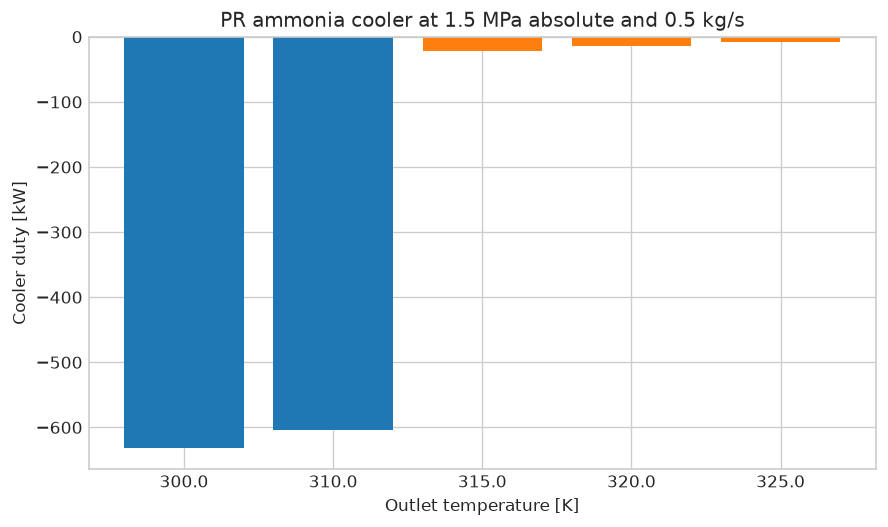

In [14]:
scenario_outlet_temperatures_kelvin = [300.0, 310.0, 315.0, 320.0, 325.0]
cooler_scenario_records = []

for outlet_temperature_kelvin in scenario_outlet_temperatures_kelvin:
    cooler_scenario_records.append(
        run_cooler_case(outlet_temperature_kelvin)
    )

cooler_scenario_table = pd.DataFrame(cooler_scenario_records)
phase_colors = {
    "gas": "tab:orange",
    "aqueous": "tab:blue",
    "liquid": "tab:blue",
}
bar_colors = [
    phase_colors.get(phase_name, "tab:gray")
    for phase_name in cooler_scenario_table["Outlet phase"]
]

figure, axis = plt.subplots(figsize=(7.5, 4.5))
axis.bar(
    cooler_scenario_table["Outlet temperature [K]"].astype(str),
    cooler_scenario_table["Duty [kW]"],
    color=bar_colors,
)
axis.set_xlabel("Outlet temperature [K]")
axis.set_ylabel("Cooler duty [kW]")
axis.set_title("PR ammonia cooler at 1.5 MPa absolute and 0.5 kg/s")
figure.tight_layout()
plt.show()

print(cooler_scenario_table.round(6).to_string(index=False))

## 14. Isenthalpic derivative and pressure-drop limiting case

The direct Joule-Thomson API is checked against two independent PH flashes around the baseline gas
state. The finite-difference estimate is

$$
\mu_{JT}\approx\frac{T(P+\Delta P,h)-T(P-\Delta P,h)}{2\Delta P}
$$

The same enthalpy is then flashed at a lower pressure. A positive coefficient predicts a lower
temperature after the pressure drop, provided the path remains within the model's valid region.

In [15]:
jt_baseline_state = make_cubic_ammonia(330.0, 1.5)
jt_target_enthalpy_joule = jt_baseline_state.getEnthalpy("J")
jt_pressure_step_bar = 0.1


def ph_flash_temperature_kelvin(pressure_bar, target_enthalpy_joule):
    state = make_cubic_ammonia(330.0, pressure_bar * 0.1)
    operations = ThermodynamicOperations(state)
    operations.PHflash(target_enthalpy_joule)
    state.initProperties()
    return state.getTemperature("K")


temperature_high_pressure_kelvin = ph_flash_temperature_kelvin(
    15.0 + jt_pressure_step_bar,
    jt_target_enthalpy_joule,
)
temperature_low_pressure_kelvin = ph_flash_temperature_kelvin(
    15.0 - jt_pressure_step_bar,
    jt_target_enthalpy_joule,
)
finite_difference_jt_k_per_bar = (
    temperature_high_pressure_kelvin - temperature_low_pressure_kelvin
) / (2.0 * jt_pressure_step_bar)
direct_jt_k_per_bar = (
    jt_baseline_state.getPhase(0).getJouleThomsonCoefficient()
)
jt_relative_residual = (
    finite_difference_jt_k_per_bar - direct_jt_k_per_bar
) / direct_jt_k_per_bar
expanded_temperature_kelvin = ph_flash_temperature_kelvin(
    5.0,
    jt_target_enthalpy_joule,
)

print(f"Direct Joule-Thomson coefficient: {direct_jt_k_per_bar:.8f} K/bar")
print(
    "Finite-difference coefficient: "
    f"{finite_difference_jt_k_per_bar:.8f} K/bar"
)
print(f"Relative residual: {jt_relative_residual:.3e}")
print(f"Isenthalpic outlet at 0.5 MPa: {expanded_temperature_kelvin:.3f} K")

Direct Joule-Thomson coefficient: 1.13522458 K/bar
Finite-difference coefficient: 1.13522446 K/bar
Relative residual: -1.084e-07
Isenthalpic outlet at 0.5 MPa: 318.566 K


## 15. Verification gates

The assertions combine an external NIST benchmark, exact thermodynamic identities, independent PH
flashes, mass/energy consistency, phase checks, expected trends, finite-value checks, and a
heat-transfer correlation validity screen. Tolerances reflect numerical differentiation and model
screening rather than measurement uncertainty.

In [16]:
verification_checks = {
    "NIST Cp benchmark within 0.2%": maximum_cp_difference_percent < 0.2,
    "Cp-Cv identities close": maximum_identity_residual < 1.0e-6,
    "Gas density decreases with temperature": (
        gas_sweep_table["Density [kg/m³]"].is_monotonic_decreasing
    ),
    "Gas viscosity increases with temperature": (
        gas_sweep_table["Viscosity [Pa s]"].is_monotonic_increasing
    ),
    "Gas conductivity increases with temperature": (
        gas_sweep_table["Conductivity [W/(m K)]"].is_monotonic_increasing
    ),
    "Liquid density decreases with temperature": (
        liquid_sweep_table["Density [kg/m³]"].is_monotonic_decreasing
    ),
    "Liquid viscosity decreases with temperature": (
        liquid_sweep_table["Viscosity [Pa s]"].is_monotonic_decreasing
    ),
    "Liquid sweep stays dense": liquid_sweep_table["Density [kg/m³]"].min() > 500.0,
    "Gas density increases with pressure": (
        pressure_sweep_table["Density [kg/m³]"].is_monotonic_increasing
    ),
    "Pressure sweep stays gaseous": pressure_sweep_table["Density [kg/m³]"].max() < 30.0,
    "Positive gas Joule-Thomson coefficient": (
        pressure_sweep_table["Joule-Thomson [K/bar]"].min() > 0.0
    ),
    "Saturation has two phases": saturated_ammonia.getNumberOfPhases() == 2,
    "Saturation density ratio is large": saturation_density_ratio > 50.0,
    "Reynolds correlation range": reynolds_number > 1.0e4,
    "Prandtl correlation range": 0.7 < prandtl_number < 160.0,
    "Positive heat-transfer coefficient": heat_transfer_coefficient_w_per_m2_k > 0.0,
    "Cooler duty is negative": baseline_cooler_result["Duty [kW]"] < 0.0,
    "Cooler energy balance closes": (
        abs(baseline_cooler_result["Energy residual [kW]"]) < 1.0e-8
    ),
    "Cooler scenarios are finite": np.isfinite(
        cooler_scenario_table["Duty [kW]"]
    ).all(),
    "Cooling duty grows across phase change": (
        abs(cooler_scenario_table.iloc[0]["Duty [kW]"])
        > 5.0 * abs(cooler_scenario_table.iloc[-1]["Duty [kW]"])
    ),
    "Joule-Thomson derivative closes": abs(jt_relative_residual) < 1.0e-5,
    "Isenthalpic pressure drop cools": expanded_temperature_kelvin < 330.0,
    "All baseline properties are finite": np.isfinite(
        baseline_table.select_dtypes(include=["number"])
    ).all().all(),
    "All baseline properties are positive": (
        baseline_table.select_dtypes(include=["number"]) > 0.0
    ).all().all(),
}

failed_checks = [
    name
    for name, passed in verification_checks.items()
    if not passed
]

assert not failed_checks, f"Verification failures: {failed_checks}"
print(f"All {len(verification_checks)} engineering checks passed.")

All 24 engineering checks passed.


## 16. Troubleshooting, validity limits, and safety

- **Run the setup first.** The import cell installs the current public PyPI package only when NeqSim
  is absent, so a clean Colab runtime needs no restart.
- **Flash before reading properties.** Call a thermodynamic operation, then `initProperties()`.
- **Inspect the phase.** A pure ammonia liquid may be named `aqueous`; the composition still contains
  only ammonia. Never infer phase from temperature alone.
- **Avoid phase boundaries in derivatives.** Central differences become meaningless if either
  perturbed state changes phase.
- **Treat cubic liquid properties as screening values.** PR and SRK spread is evidence that density,
  heat capacity, and transport properties need an ammonia-specific project benchmark.
- **Do not extrapolate.** Near the critical point, through two-phase flow, or outside a correlation's
  fitted range, use validated reference-property data and appropriate equipment methods.
- **Respect ammonia hazards.** Anhydrous ammonia is toxic and corrosive in the presence of moisture;
  real design requires applicable codes, materials review, relief analysis, detection, ventilation,
  and independent process-safety assessment.

The heat-transfer example excludes boiling, condensation, fouling, roughness, maldistribution, and
pressure drop. The process cooler is an equilibrium energy-balance model, not a mechanical design.

In [17]:
representative_results = pd.DataFrame(
    {
        "Result": [
            "Maximum NIST Cp difference",
            "Maximum Cp-Cv identity residual",
            "Gas density model spread",
            "Liquid density model spread",
            "Heat-transfer coefficient",
            "Baseline cooler duty",
            "Baseline cooler energy residual",
            "Joule-Thomson coefficient",
            "Isenthalpic outlet temperature",
        ],
        "Value": [
            maximum_cp_difference_percent,
            maximum_identity_residual,
            gas_density_spread_percent,
            liquid_density_spread_percent,
            heat_transfer_coefficient_w_per_m2_k,
            baseline_cooler_result["Duty [kW]"],
            baseline_cooler_result["Energy residual [kW]"],
            direct_jt_k_per_bar,
            expanded_temperature_kelvin,
        ],
        "Unit": [
            "%",
            "-",
            "%",
            "%",
            "W/(m² K)",
            "kW",
            "kW",
            "K/bar",
            "K",
        ],
    }
)

print(representative_results.to_string(index=False))

                         Result         Value     Unit
     Maximum NIST Cp difference  1.168995e-01        %
Maximum Cp-Cv identity residual  7.776009e-09        -
       Gas density model spread  8.476481e+00        %
    Liquid density model spread  6.397827e+00        %
      Heat-transfer coefficient  6.425335e+01 W/(m² K)
           Baseline cooler duty -2.227718e+01       kW
Baseline cooler energy residual  3.552714e-15       kW
      Joule-Thomson coefficient  1.135225e+00    K/bar
 Isenthalpic outlet temperature  3.185659e+02        K


## 17. Summary, exercises, and references

NeqSim separates equilibrium, caloric, and transport calculations while exposing phase-specific
properties for process use. The ammonia-specific EOS reproduces the NIST dilute-gas heat-capacity
correlation closely over the tested range. PR gives robust phase-aware workflows and exact internal
thermodynamic identities, but PR/SRK spread shows why compressed-liquid results need independent
validation. A stream and cooler connect those properties to energy balances, and the scenario study
shows why phase changes invalidate single-phase heat-transfer shortcuts.

**Further exercises**

1. Repeat the gas sweep at 0.5 MPa and explain changes in $Z$ and $\mu_{JT}$.
2. Replace the tube diameter and mass flow, then map the laminar-to-turbulent transition.
3. Compare PR and SRK cooler duties without retuning either model.
4. Add pressure drop only after choosing a validated single- or two-phase correlation.
5. Benchmark liquid density and viscosity against an authoritative modern ammonia dataset licensed
   for your project.

**Authoritative references**

- [NeqSim physical-properties documentation](https://equinor.github.io/neqsim/physical_properties/)
- [NeqSim thermodynamic-model guidance](https://equinor.github.io/neqsim/thermo/thermodynamic_models.html)
- [NeqSim thermodynamics recipes](https://equinor.github.io/neqsim/cookbook/thermodynamics-recipes.html)
- [NeqSim process recipes](https://equinor.github.io/neqsim/cookbook/process-recipes.html)
- [NIST Chemistry WebBook: ammonia ideal-gas heat capacity](https://webbook.nist.gov/cgi/cbook.cgi?ID=C7664417&Table=on&Type=JANAFG)
- [NIST Bureau of Standards ammonia property tables](https://www.govinfo.gov/content/pkg/GOVPUB-C13-477effb940f2accaffa92b2a30d5fb7b/pdf/GOVPUB-C13-477effb940f2accaffa92b2a30d5fb7b.pdf)